# Forecasting ML Pipeline with Prophet
## Personalized Home Energy Saver — Global Model, Per-Appliance

### What this notebook does
1. Loads the raw smart-home energy readings (500 homes, 10 appliance types, 1 year).
2. Builds one clean, equally-spaced **daily** time series **per appliance** by aggregating
   every home together — this is the *global* model (all households) trained *per appliance*.
3. Fits a **Prophet** model per appliance using outdoor temperature as an extra regressor.
4. Forecasts the held-out test window and reports **MAE / RMSE / MAPE** per appliance.
5. Saves the fitted models, forecasts and a metrics summary to `Backend/Artifacts/`.

> Personalisation note: the *global* model captures the aggregate behaviour of an appliance
> type across all homes. A future extension can narrow the scope to a single `Home ID`
> for truly personalised forecasts (see the final markdown cell).

In [23]:
# ============================================================================
# CELL 1 - Imports
# ============================================================================
# Purpose : import every library used later in the pipeline. The tunable
#           configuration (paths, target columns, Prophet parameters) lives
#           in a single block in CELL 3.
#
# NOTE    : forecast accuracy is measured with scikit-learn:
#             mean_absolute_error              -> MAE
#             mean_squared_error  (sqrt of)    -> RMSE
#             mean_absolute_percentage_error   -> MAPE (as a percent)
#           scikit-learn is a declared dependency of this project.

import json  # dump metric summaries to disk
import logging  # quieten the noisy cmdstanpy logger (see CELL 3)
import os  # path / mkdir helpers
import pickle  # persist trained Prophet models
from datetime import datetime, timezone  # time-stamp used for saved artifact names
from pathlib import Path  # cross-platform path handling

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from icecream import ic  # debug print() replacement
from prophet import Prophet  # the forecasting engine
from sklearn.metrics import (
    mean_absolute_error,  # MAE  (kWh/day)
    mean_absolute_percentage_error,  # MAPE (fraction; *100 -> percent)
    mean_squared_error,  # MSE  (kWh/day)^2 -> RMSE = sqrt(MSE)
)

%matplotlib inline

In [24]:
# ============================================================================
# CELL 2 - Path Resolution Helpers (locate dataset + Backend folder)
# ============================================================================
# Purpose : the notebook may be launched from Backend/Notebook, Backend/ or
#           even the repo root, so instead of trusting a fixed CWD we SEARCH
#           upward/downward from the possible launch points until the dataset
#           file is found, and derive the Backend/ folder from the file that
#           was actually located.


def resolve_dataset() -> Path:
    """Return the absolute path to the raw CSV, wherever the notebook is launched."""
    # Candidate launch points: the current working directory and the directory
    # that contains this notebook file (they usually coincide under Jupyter).
    launch_points = [Path.cwd()]
    if Path("ml_model_training.ipynb").exists():
        launch_points.append(Path(os.path.abspath(path="ml_model_training.ipynb")).parent)
        ic(f"Launch point of the notebook: {launch_points[-1]}")

    for start in launch_points:
        # Upward search (launched from Notebook/ or Backend/) ...
        for level in (start, start.parent, start.parent.parent):
            candidate = level / "Dataset" / "smart_home_energy_consumption_large.csv"
            if candidate.exists():
                return candidate
        # ... plus a downward search (launched from the repo root).
        downward = (
            start / "Backend" / "Dataset" / "smart_home_energy_consumption_large.csv"
        )
        if downward.exists():
            return downward

    # Last resort: relative to the current working directory.
    return Path.cwd() / "Dataset" / "smart_home_energy_consumption_large.csv"


def find_backend_dir(dataset_path: Path) -> Path:
    """Return the <project>/Backend folder that owns the given dataset file."""
    # The dataset lives in <Backend>/Dataset/, so walk upward from the
    # dataset's folder until we hit a directory literally named "Backend".
    # (Old code used .parent.parent which breaks when launched from Backend/.)
    for parent in dataset_path.parents:
        if parent.name == "Backend":
            return parent

    # Fallback for unusual layouts: <Dataset>/ -> <Backend>/
    return dataset_path.parent.parent

In [25]:
# ============================================================================
# CELL 3 - Global Configuration & Output Directories
# ============================================================================
# Purpose : ONE tunable configuration block for the whole pipeline. Everything
#           defined here is shared by every per-appliance Prophet model, so a
#           change affects the entire experiment in a single place.
#
# Sections :
#   1. Paths                 - where the data lives and where artifacts go
#   2. Dataset column names  - target series + weather regressor
#   3. Train / test split    - chronological split size
#   4. Prophet model config  - shared hyper-parameters
#   5. Logging policy        - keep the console readable while training
#   6. Output directories    - create the artifact folders if missing

# ============================================================================
# 1. Paths ------------------------------------------------------------------
# The dataset is located by CELL 2 (search upward/downward from the launch
# point). From that file we derive Backend/Artifacts/ without assuming a
# particular working directory.
DATASET_PATH = resolve_dataset()
BACKEND_DIR   = find_backend_dir(DATASET_PATH)     # <project>/Backend
ARTIFACTS_DIR = BACKEND_DIR / "Artifacts"
MODELS_DIR    = ARTIFACTS_DIR / "Models"
PRED_DIR      = ARTIFACTS_DIR / "Predictions"
ACCURACY_DIR   = ARTIFACTS_DIR / "Accuracy"

# ============================================================================
# 2. Dataset column names ----------------------------------------------------
# TARGET_COL : the numeric column we forecast (total daily energy in kWh).
TARGET_COL = "Energy Consumption (kWh)"

# TEMP_COL   : the temperature header is "Outdoor Temperature (°C)" - it
#              contains a non-ASCII degree sign, so hard-coding the string is
#              fragile against encoding/header differences. We detect it by a
#              name *search* after the CSV is loaded (CELL 5) and store the
#              winning header name here. Left None until then.
TEMP_COL = None

# ============================================================================
# 3. Chronological train / test split ----------------------------------------
# Keep the LAST N days of each daily series as a held-out test set.
# A full year of data (~366 days) with 73 test days is roughly an 80/20 split.
TEST_DAYS = 73

# ============================================================================
# 4. Shared Prophet configuration (applied to EVERY appliance) ----------------
#   - yearly_seasonality=False  : we only have ~1 full yearly cycle; a yearly
#     term learned from a single cycle tends to overfit (Prophet expects >= 2).
#   - weekly_seasonality=True   : weekday/weekend behaviour is very visible in
#     household energy usage.
#   - seasonality_mode="multiplicative" : seasonal swings scale with the level.
#     SAFE because our daily energy sums are strictly positive (0 <= y < inf).
PROPHET_CONFIG = {
    "growth": "linear",                 # linear trend with automatic changepoints
    "yearly_seasonality": False,        # not enough data for a stable yearly term
    "weekly_seasonality": True,         # week-day cycle
    "daily_seasonality": False,         # daily aggregates only, no intra-day info
    "seasonality_mode": "additive",  # seasonal effect scales with the level
    "changepoint_prior_scale": 0.05,    # moderate trend-changer flexibility
    "seasonality_prior_scale": 10.0,    # default strength of the seasonal terms
    "n_changepoints": 25,               # max number of auto-detected trend breaks
    "interval_width": 0.95,             # width of the uncertainty bands
}

# ============================================================================
# 5. Logging policy ----------------------------------------------------------
# Prophet / cmdstanpy log a LOT of benign INFO text while fitting. Raise the
# cmdstanpy logger threshold so the console stays readable - WITHOUT hiding
# real warnings from pandas / numpy (the old code silenced EVERYTHING).
logging.getLogger(name="cmdstanpy").setLevel(level=logging.WARNING)

# ============================================================================
# 6. Output directories ------------------------------------------------------
# Create the artifact folders up front (no-op when they already exist).
for directory in (ARTIFACTS_DIR, MODELS_DIR, PRED_DIR, ACCURACY_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ic| f"Launch point of the notebook: {launch_points[-1]}": 'Launch point of the notebook: c:\\Users\\USER\\Documents\\Gen AI Projects\\AI-Powered-Smart-Home-Energy-Optimizer\\Backend\\Notebook'


In [26]:
# ============================================================================
# CELL 4 - Setup Sanity Check
# ============================================================================
# Purpose : confirm the dataset was located and the artifact folders created
#           before we start loading the CSV.

print("Setup OK")
print("  Dataset :", DATASET_PATH.resolve())
print("  Output  :", ARTIFACTS_DIR.resolve())

Setup OK
  Dataset : C:\Users\USER\Documents\Gen AI Projects\AI-Powered-Smart-Home-Energy-Optimizer\Backend\Dataset\smart_home_energy_consumption_large.csv
  Output  : C:\Users\USER\Documents\Gen AI Projects\AI-Powered-Smart-Home-Energy-Optimizer\Backend\Artifacts


In [27]:
# ============================================================================
# CELL 5 - Load the Raw Dataset
# ============================================================================
# Purpose : read the CSV into a DataFrame and confirm its basic shape.
#
# FIX     : the CSV stores the temperature header as "Outdoor Temperature (°C)".
#           Opening the file with the default UTF-8 codec either raises or
#           garbles non-ASCII characters, so we force a latin-1 read.
df_raw = pd.read_csv(filepath_or_buffer=DATASET_PATH, encoding="latin-1")

# Strip accidental leading/trailing whitespace from the column headers.
df_raw.columns = [col.strip() for col in df_raw.columns]
ic(f"Column names after stripping: {df_raw.columns}")

# Identify the temperature column by name search (robust against encodings).
TEMP_COL = next(col for col in df_raw.columns if "Temperature" in col)

print(f"Rows x Columns : {df_raw.shape[0]} x {df_raw.shape[1]}\n")
print(f"Temperature column detected -> '{TEMP_COL}'")
df_raw.head()

ic| f"Column names after stripping: {df_raw.columns}": '''Column names after stripping: Index(['Home ID', 'Appliance Type', 'Energy Consumption (kWh)', 'Time', 'Date',
                                                               'Outdoor Temperature (Â°C)', 'Season', 'Household Size'],
                                                              dtype='str')'''


Rows x Columns : 100000 x 8

Temperature column detected -> 'Outdoor Temperature (Â°C)'


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (Â°C),Season,Household Size
0,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
1,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
3,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
4,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5


In [28]:
# ============================================================================
# CELL 6 - Validation & Datetime Construction
# ============================================================================
# Purpose : (a) sanity-check missing values and column types,
#           (b) build a SINGLE datetime column (`measurement_datetime`) from the separate Date
#               and Time strings (Prophet requires one datetime column),
#           (c) add small calendar features used later for diagnostics,
#           (d) defensively (re)build the categorical Season from the month.
#
# FIX     : earlier versions built a second, renamed DataFrame (`df`) with a
#           hard-coded temperature header, enforced dtypes on it, and then
#           NEVER used it again - every downstream cell reads `df_raw`.
#           Removed the dead rename/copy; we now coerce dtypes in place on the
#           original columns and reference TEMP_COL (never a hard-coded string)
#           so nothing depends on the exact CSV encoding.

print("Missing values per column (should all be 0):")
print(df_raw.isna().sum(), "\n")

# Robust numeric coercion - guarantees floats even if the CSV stored the
# values as strings on some platform.
df_raw[TARGET_COL] = pd.to_numeric(arg=df_raw[TARGET_COL], errors="coerce")
df_raw[TEMP_COL]   = pd.to_numeric(arg=df_raw[TEMP_COL],   errors="coerce")

# Combine the separate Date + Time strings into one clock timestamp.
# `errors="coerce"` turns malformed strings into NaT instead of failing.
df_raw["measurement_datetime"] = pd.to_datetime(
    arg=df_raw["Date"].astype(str) + " " + df_raw["Time"].astype(str),
    format="%Y-%m-%d %H:%M",
    errors="coerce",
)

# Drop rows with an unparseable timestamp or a missing energy value.
before = len(df_raw)
ic(before)
df_raw = df_raw.dropna(subset=["measurement_datetime", TARGET_COL]).copy()
print(f"Dropped {before - len(df_raw)} malformed rows.")

# --- Season imputation (defensive) -----------------------------------------
# The CSV already ships a complete 'Season' column, but if a future snapshot
# contains gaps we rebuild any missing value deterministically from the month
# so downstream grouping / diagnostics never hit NaN.
month_to_season = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall",
}
df_raw["Season"] = df_raw["Season"].fillna(
    df_raw["measurement_datetime"].dt.month.map(month_to_season)
)

# Chronological order makes every downstream slice deterministic.
df_raw = df_raw.sort_values(by="measurement_datetime").reset_index(drop=True)

print(f"Remaining events   : {len(df_raw):,}")
print(f"Season values      : {sorted(df_raw['Season'].dropna().unique())}")
df_raw[["Home ID", "Appliance Type", TARGET_COL, "measurement_datetime", TEMP_COL, "Season"]].head()
# df_raw.head()


Missing values per column (should all be 0):
Home ID                      0
Appliance Type               0
Energy Consumption (kWh)     0
Time                         0
Date                         0
Outdoor Temperature (Â°C)    0
Season                       0
Household Size               0
dtype: int64 



ic| before: 100000


Dropped 0 malformed rows.
Remaining events   : 100,000
Season values      : ['Fall', 'Spring', 'Summer', 'Winter']


,Home ID,Appliance Type,Energy Consumption (kWh),measurement_datetime,Outdoor Temperature (Â°C),Season
0,140,Lights,1.00,2023-01-01 00:07:00,-5.9,Winter
1,298,Lights,1.09,2023-01-01 00:13:00,22.0,Winter
2,469,Fridge,0.30,2023-01-01 00:24:00,-1.2,Winter
3,398,Fridge,0.50,2023-01-01 00:26:00,35.8,Winter
4,293,Washing Machine,1.12,2023-01-01 00:30:00,2.7,Winter


In [29]:
# ============================================================================
# CELL 7 - Exploratory Snapshot (coverage & distribution)
# ============================================================================
# Purpose : a quick sanity check on the data we are about to model:
#           time coverage, number of homes, and events per appliance type.

print(
    "Timestamp coverage :",
    df_raw["measurement_datetime"].min(),
    "->",
    df_raw["measurement_datetime"].max(),
)
print("Distinct homes     :", df_raw["Home ID"].nunique())
print("Appliance types    :", df_raw["Appliance Type"].nunique())
print("\nReadings per appliance:")
print(df_raw["Appliance Type"].value_counts())

Timestamp coverage : 2023-01-01 00:07:00 -> 2024-01-01 23:53:00
Distinct homes     : 500
Appliance types    : 10

Readings per appliance:
Appliance Type
Lights              10201
Dishwasher          10095
Air Conditioning    10067
Heater              10018
Washing Machine      9953
Microwave            9947
Computer             9944
Oven                 9939
Fridge               9931
TV                   9905
Name: count, dtype: int64


In [30]:
print("\nReadings per home number of per appliance count:")
print(df_raw.groupby(by=["Home ID", "Appliance Type"]).size())


Readings per home number of per appliance count:
Home ID  Appliance Type  
1        Air Conditioning    23
         Computer            23
         Dishwasher          18
         Fridge              20
         Heater              22
                             ..
500      Lights              13
         Microwave           13
         Oven                21
         TV                  14
         Washing Machine     21
Length: 5000, dtype: int64


In [31]:
df_raw.head()

,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (Â°C),Season,Household Size,measurement_datetime
0,140,Lights,1.00,00:07,2023-01-01,-5.9,Winter,1,2023-01-01 00:07:00
1,298,Lights,1.09,00:13,2023-01-01,22.0,Winter,1,2023-01-01 00:13:00
2,469,Fridge,0.30,00:24,2023-01-01,-1.2,Winter,3,2023-01-01 00:24:00
3,398,Fridge,0.50,00:26,2023-01-01,35.8,Winter,2,2023-01-01 00:26:00
4,293,Washing Machine,1.12,00:30,2023-01-01,2.7,Winter,3,2023-01-01 00:30:00


In [32]:
# ============================================================================
# CELL 8 - Daily Time Series: Per-Home First, Then Cross-Home per Appliance
# ============================================================================
# DESIGN DECISION
# ---------------
# "Global model, per appliance" = we train ONE forecast model per appliance
# *type* (Fridge, Heater, ...) but the model sees the aggregated readings of
# ALL 500 homes. That pool is much smoother than any single home's events,
# which is exactly what makes the forecast stable.
#
# The raw data is event-based (a reading per appliance episode), which is NOT
# an equally-spaced time series. Prophet expects one regular sampling interval,
# so we resample to DAILY buckets in TWO stages:
#
#   Stage 1 - PER-HOME daily panel ("home_daily")
#       One row per (home, appliance, date) with daily_kwh, avg/min/max temp,
#       household size and event count, plus calendar features (day_of_week, weekend,
#       month, season). Kept as a reusable, Prophet-friendly intermediate: it
#       is exactly the foundation the PERSONALISED per-home models need.
#
#   Stage 2 - CROSS-HOME daily series (Prophet-ready, per appliance)
#       Two aggregations derived from the per-home panel:
#         "daily[app]"      -> energy = SUM(daily_kwh)  total kWh for the day
#         "appliance_daily" -> y      = MEAN(daily_kwh) per-home average energy
#       "daily" is the primary training input (matches the persisted artefacts,
#       metrics and plots downstream). "appliance_daily" is an alternative,
#       scale-free view kept for later per-home benchmarking / analysis.

# ---- Stage 1: per-home daily panel ----------------------------------------
# Named aggregation assigns clean column names directly (pandas 2.0+).
# The groupby key is measurement_datetime normalised to calendar days (midnight Timestamps).
home_daily = (
    df_raw.groupby(
        by=["Home ID", "Appliance Type", df_raw["measurement_datetime"].dt.normalize()],
        as_index=False,
    ).agg(
        daily_kwh=(TARGET_COL, "sum"),  # total kWh for that home+appliance+day
        avg_temp=(TEMP_COL, "mean"),  # mean outdoor temperature that day
        min_temp=(TEMP_COL, "min"),  # temperature extremes (weather signal)
        max_temp=(TEMP_COL, "max"),
        hh_size=("Household Size", "max"),  # household is fixed per home -> max is safe
        events=(TARGET_COL, "count"),  # how many event-readings fed the sum
    )
).rename(columns={"measurement_datetime": "Date_per_Home"})

# Calendar features for later use (grouping by weekday/season, diagnostics...).
home_daily["day_of_week"] = home_daily["Date_per_Home"].dt.dayofweek      # 0 = Monday
home_daily["is_weekend"] = (home_daily["day_of_week"] >= 5).astype(int)  # 1 on weekend
home_daily["month"]      = home_daily["Date_per_Home"].dt.month
home_daily["season"]     = home_daily["month"].map(month_to_season)  # from CELL 6
home_daily = home_daily.sort_values(["Appliance Type", "Home ID", "Date_per_Home"]).reset_index(drop=True)


# ---- Stage 2a: GLOBAL per-appliance series (SUM over homes, the model input) --
daily = {}     # {appliance_name: DataFrame[measurement_datetime, energy, temp]}

for app in sorted(home_daily["Appliance Type"].unique()):
    daily[app] = (
        home_daily[home_daily["Appliance Type"] == app]
        .groupby("Date_per_Home", as_index=False)
        .agg(
            energy=("daily_kwh", "sum"),  # total daily kWh across ALL homes
            temp=("avg_temp", "mean"),
            is_weekend=("is_weekend", "max"),
            hh_size=("hh_size", "mean"),
        )  # mean outdoor temperature
        .rename(columns={"Date_per_Home": "measurement_datetime"})
        .sort_values("measurement_datetime")
        .reset_index(drop=True)
    )

# ---- Stage 2b: alternative scale (MEAN across homes, for later use) --------
appliance_daily = (
    home_daily
    .groupby(["Appliance Type", "Date_per_Home"], as_index=False)
    .agg(
        y=("daily_kwh", "mean"),            # kWh per home per day (avg of homes)
        avg_temp=("avg_temp", "mean"),
        hh_size=("hh_size", "mean"),
        is_weekend=("is_weekend", "max"),
    )
    .rename(columns={"Date_per_Home": "Date"})
    .sort_values(["Appliance Type", "Date"])
    .reset_index(drop=True)
)

# Drop rows lacking core fields (defensive: requires measurement_datetime, target and regressor).
appliance_daily = appliance_daily.dropna(subset=["Date", "y", "avg_temp"])

print(f"Per-home daily panel    : {len(home_daily):,} rows")
print(f"Global daily series     : {len(daily)} appliances (SUM  -> total kWh/day)")
print(f"Per-home avg series     : {len(appliance_daily):,} rows (MEAN -> kWh/home/day)")

Per-home daily panel    : 97,422 rows
Global daily series     : 10 appliances (SUM  -> total kWh/day)
Per-home avg series     : 3,660 rows (MEAN -> kWh/home/day)


In [33]:
print("\nFirst rows for the home daily panel:")
home_daily.head()


First rows for the home daily panel:


,Home ID,Appliance Type,Date_per_Home,daily_kwh,avg_temp,min_temp,max_temp,hh_size,events,day_of_week,is_weekend,month,season
0,1,Air Conditioning,2023-01-07,2.77,-3.3,-3.3,-3.3,3,1,5,1,1,Winter
1,1,Air Conditioning,2023-01-14,4.80,2.1,2.1,2.1,4,1,5,1,1,Winter
2,1,Air Conditioning,2023-01-15,3.13,1.0,1.0,1.0,2,1,6,1,1,Winter
3,1,Air Conditioning,2023-01-19,3.10,32.4,32.4,32.4,4,1,3,0,1,Winter
4,1,Air Conditioning,2023-01-29,4.16,34.6,34.6,34.6,3,1,6,1,1,Winter


In [34]:
print("\nFirst rows for the Heater series (global model input):")
daily["Heater"].head()


First rows for the Heater series (global model input):


,measurement_datetime,energy,temp,is_weekend,hh_size
0,2023-01-01,136.79,16.018293,1,3.073171
1,2023-01-02,69.20,16.934211,0,2.789474
2,2023-01-03,94.52,15.916000,0,2.960000
3,2023-01-04,119.40,18.475806,0,2.870968
4,2023-01-05,105.13,16.620370,0,3.296296


In [35]:
print("\nFirst rows for the per-appliance daily panel (mean across homes):")
appliance_daily.head()


First rows for the per-appliance daily panel (mean across homes):


,Appliance Type,Date,y,avg_temp,hh_size,is_weekend
0,Air Conditioning,2023-01-01,3.733448,15.896552,3.034483,1
1,Air Conditioning,2023-01-02,3.922308,17.776923,3.269231,0
2,Air Conditioning,2023-01-03,3.571905,10.247619,2.952381,0
3,Air Conditioning,2023-01-04,3.718333,14.780000,3.233333,0
4,Air Conditioning,2023-01-05,3.623750,14.743750,2.925000,0


In [36]:
# ============================================================================
# CELL 9 - Chronological Train / Test Split
# ============================================================================
# Purpose : split one daily series into TRAIN (past) and TEST (future) WITHOUT
#           shuffling. Random shuffling would leak the future into training and
#           is the classic time-series modelling mistake.
#
# A separate helper converts a training frame into Prophet's expected schema:
#     ds : datetime, y : value to forecast, temp : extra regressor.

def split_train_test(series_df, test_days=TEST_DAYS):
    """Return (train, test) - the first len-test_days rows vs the last ones."""
    cut = max(len(series_df) - test_days, 0)
    return series_df.iloc[:cut].copy(), series_df.iloc[cut:].copy()


def to_prophet(frame):
    """Rename/select the columns Prophet expects: ds, y, + the regressor."""
    out = frame[["measurement_datetime", "energy"]].copy()
    out.columns = ["ds", "y"]              # Prophet hard-requires 'ds' and 'y'
    out["temp"] = frame["temp"].values     # keep the weather regressor
    out["is_weekend"] = frame["is_weekend"].values   # weekend/weekday regressor
    out["hh_size"]    = frame["hh_size"].values      # household-size regressor
    return out


# Sanity demo: show the split point for one appliance.
train_demo, test_demo = split_train_test(series_df=daily["Heater"])
print("Heater train :", train_demo["measurement_datetime"].min().date(), "->", train_demo["measurement_datetime"].max().date(),
      f"({len(train_demo)} days)")
print("Heater test  :", test_demo["measurement_datetime"].min().date(), "->", test_demo["measurement_datetime"].max().date(),
      f"({len(test_demo)} days)")


Heater train : 2023-01-01 -> 2023-10-20 (293 days)
Heater test  : 2023-10-21 -> 2024-01-01 (73 days)


In [37]:
# ============================================================================
# CELL 10 - Evaluation Metrics (scikit-learn wrappers)
# ============================================================================
# Purpose : thin wrappers around scikit-learn's error metrics so Cell 13 can
#           keep calling short helpers named mae() / rmse() / mape().
#
# NOTE    : our daily sums are strictly positive (>0 kWh) for every appliance,
#           so sklearn's MAPE cannot divide by zero here.

def mae(y_true, y_pred):
    """Mean Absolute Error (kWh/day) - robust to outliers."""
    return float(mean_absolute_error(y_true, y_pred))


def rmse(y_true, y_pred):
    """Root Mean Squared Error (kWh/day) - penalises large misses harder."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (%) - sklearn returns a fraction."""
    return float(mean_absolute_percentage_error(y_true, y_pred) * 100.0)


print("Metrics helpers ready -> MAE / RMSE / MAPE (via scikit-learn).")

Metrics helpers ready -> MAE / RMSE / MAPE (via scikit-learn).


In [38]:
# ============================================================================
# CELL 11 - Train One Prophet Model per Appliance (Global, All Homes)
# ============================================================================
# NOTES
#  - Three extra regressors are registered and MUST be present in both the
#    training frame and the future/prediction frame:
#      * temp        - outdoor temperature (weather-driven demand)
#      * is_weekend  - weekend/weekday effect on household energy use
#      * hh_size     - average household size across the 500 homes
#  - We deliberately do NOT pass `show_progress=` to `.fit()`: the installed
#    cmdstanpy 1.3.0 does not accept that keyword (TypeError) - a known
#    prophet/cmdstanpy version mismatch. Defaults are fine.
models = {}    # {appliance: {"model", "train", "test", "forecast"}}

for app in sorted(daily.keys()):
    frame      = daily[app]
    train, test = split_train_test(series_df=frame)          # chronological split
    prophet_df = to_prophet(frame=train)   # columns: ds, y, temp, is_weekend, hh_size


    model = Prophet(**PROPHET_CONFIG)              # shared hyper-parameters
    model.add_regressor(name="temp", standardize=True)                    # weather-informed demand
    model.add_regressor(name="is_weekend", standardize=True)              # weekend vs weekday
    model.add_regressor(name="hh_size", standardize=True)      
    model.fit(prophet_df)                          # MAP estimation (fast)

    models[app] = {"model": model, "train": train, "test": test}
    print(f"{app:16s} trained | train={len(train)}d test={len(test)}d")


Air Conditioning trained | train=293d test=73d
Computer         trained | train=293d test=73d
Dishwasher       trained | train=293d test=73d
Fridge           trained | train=293d test=73d
Heater           trained | train=293d test=73d
Lights           trained | train=293d test=73d
Microwave        trained | train=293d test=73d
Oven             trained | train=293d test=73d
TV               trained | train=293d test=73d
Washing Machine  trained | train=293d test=73d


In [39]:
# ============================================================================
# CELL 12 - Forecast the Held-Out Test Window
# ============================================================================
# Purpose : for every appliance, predict the whole test horizon.
#           The known future temperatures from the dataset are fed back in as
#           the regressor values (in production they would come from a weather
#           forecast). Prophet outputs the mean `yhat` plus uncertainty bands.
predictions = {}   # {appliance: DataFrame[measurement_datetime, actual, yhat, yhat_lower, yhat_upper]}
# ic(models)
for app, bag in models.items():
    model = bag["model"]
    test  = bag["test"]

    # Future frame needs `ds` + every regressor ("temp", "is_weekend", "hh_size").
    # The 'y' column is filled by Prophet itself, so we pass only ds + regressors.
    future = test[["measurement_datetime", "temp", "is_weekend", "hh_size"]].rename(
        columns={"measurement_datetime": "ds"}   # Prophet.predict needs literal ds
    )
    fc     = model.predict(df=future)

    predictions[app] = pd.DataFrame(data={
        "measurement_datetime": test["measurement_datetime"].values,
        "actual":      test["energy"].values,
        "yhat":        fc["yhat"].values,
        "yhat_lower":  fc["yhat_lower"].values,
        "yhat_upper":  fc["yhat_upper"].values,
    })

print(f"Forecast produced for {len(predictions)} appliances over {len(test)} days each.")
predictions["Heater"].head()
# ic(predictions)

Forecast produced for 10 appliances over 73 days each.


,measurement_datetime,actual,yhat,yhat_lower,yhat_upper
0,2023-10-21,79.02,101.364513,63.065511,138.282316
1,2023-10-22,85.97,99.015765,62.781002,135.951416
2,2023-10-23,80.76,95.935276,58.711232,132.738123
3,2023-10-24,98.35,97.734919,60.542133,134.558245
4,2023-10-25,111.03,106.372896,69.263184,142.252652


In [40]:
# ============================================================================
# CELL 13 - Evaluate Forecasts (MAE / RMSE / MAPE per Appliance)
# ============================================================================
# Purpose : compare predicted vs actual daily energy for every appliance and
#           collect the results in one tidy summary DataFrame.
#
# NOTE    : energy cannot be negative -> clip the forecast at zero before the
#           error numbers are computed (a common real-world correction).
summary = []

for app, preds in predictions.items():
    yhat    = np.maximum(preds["yhat"].values, 0.0)   # physical lower bound
    actual  = preds["actual"].values

    summary.append({
        "appliance":  app,
        "mae_kwh":    round(number=mae(y_true=actual, y_pred=yhat), ndigits=3),
        "rmse_kwh":   round(number=rmse(y_true=actual, y_pred=yhat), ndigits=3),
        "mape_pct":   round(number=mape(y_true=actual, y_pred=yhat), ndigits=2),
    })

summary_df = pd.DataFrame(data=summary).sort_values(by="rmse_kwh").reset_index(drop=True)
print("Per-appliance forecast accuracy on the held-out test window:\n")
print(summary_df.to_string(index=False))


Per-appliance forecast accuracy on the held-out test window:

       appliance  mae_kwh  rmse_kwh  mape_pct
          Fridge    1.467     1.863     18.64
              TV    4.722     5.811     17.46
        Computer    5.128     6.344     18.35
 Washing Machine    5.221     6.575     21.18
          Lights    5.159     6.614     19.40
       Microwave    5.294     6.715     18.05
            Oven    5.585     6.784     20.15
      Dishwasher    5.630     7.093     20.31
          Heater   13.754    17.181     15.90
Air Conditioning   17.926    21.345     20.87


In [41]:
# ============================================================================
# CELL 14 - Persist Models, Forecasts, Metrics & Model Registry
# ============================================================================
# Purpose : save everything a downstream service needs:
#           1. the fitted Prophet objects (pickle) in artifacts/models/, 
#           2. per-appliance CSV of actuals + forecast + uncertainty bands,
#           3. a single metrics JSON that can be consumed by an API/UI,
#           4. a model_registry JSON (per appliance: pickle path, regressors
#              used, train/test split date) powering next-day inference.
#
# NOTE    : using UTC keeps file naming deterministic across environments while
#           avoiding the timezone-naive warning from datetime.now() without tz.
stamp = datetime.now(tz=timezone.utc).strftime(format="%Y%m%d_%H%M%S")

def slug(appliance):
    # "Air Conditioning" -> "air_conditioning" (safe file name).
    return appliance.replace(" ", "_").lower()

# Per-appliance accuracy -> easy lookup dict for the registry records.
# IMPORTANT: iterate over the DataFrame records instead of itertuples(),
# because pandas may emit plain tuples unless a named row class is requested.
# Plain tuples do not support attribute access such as row.mae_kwh.
metric_lookup = {}
for row in summary_df.to_dict(orient="records"):
    metric_lookup[row["appliance"]] = {
        "mae_kwh":  row["mae_kwh"],
        "rmse_kwh": row["rmse_kwh"],
        "mape_pct": row["mape_pct"],
    }

# Make the registry type explicit so downstream cells see a stable
# shape instead of an untyped `{}`. This also removes the notebook's
# "str | list[str] | dict[str, Unknown] | None" ambiguity for values.
model_registry: dict[str, dict[str, object]] = {}

for app, bag in models.items():
    ic(f"Processing appliance: {app}")
    # ic(f"Bag: {bag}")
    
    # 1) Persist the fitted Prophet object as a pickle.
    model_path = MODELS_DIR / f"prophet_{slug(appliance=app)}.pkl"
    with open(file=model_path, mode="wb") as fh:
        pickle.dump(obj=bag["model"], file=fh)

    # 2) Save the test-window forecast CSV (actual vs forecast vs bands).
    pred_path = PRED_DIR / f"predictions_{slug(appliance=app)}.csv"
    predictions[app].to_csv(path_or_buf=pred_path, index=False)

    # 3) Registration record - regressors MUST be the names the model saw at
    #    fit time (daily[app] names the weather column 'temp', not 'avg_temp').
    split_date = bag["train"]["measurement_datetime"].max()
    model_registry[app] = {
        "model_path": str(object=model_path.resolve()),
        "regressors": ["temp", "is_weekend", "hh_size"],
        "split_date": str(object=pd.to_datetime(arg=split_date).date()),
        "metrics": metric_lookup.get(app),
    }

# 4) Machine-readable accuracy summary for the rest of the platform.
metrics_path = ACCURACY_DIR / f"metrics_{stamp}.json"
with open(file=metrics_path, mode="w", encoding="utf-8") as fh:
    json.dump(obj=summary_df.to_dict(orient="records"), fp=fh, indent=2)

# 5) Save the clean registry with normalized absolute paths.
registry_path = ACCURACY_DIR / "model_registry.json"
with open(file=registry_path, mode="w", encoding="utf-8") as fh:
    json.dump(obj=model_registry, fp=fh, indent=2)

print(f"Persisted {len(models)} models + forecasts + metrics + registry to:")
print(" ", ACCURACY_DIR.resolve())
print(f"Registry saved -> {registry_path.resolve()}")

ic| f"Processing appliance: {app}": 'Processing appliance: Air Conditioning'
ic| f"Processing appliance: {app}": 'Processing appliance: Computer'
ic| f"Processing appliance: {app}": 'Processing appliance: Dishwasher'
ic| f"Processing appliance: {app}": 'Processing appliance: Fridge'
ic| f"Processing appliance: {app}": 'Processing appliance: Heater'
ic| f"Processing appliance: {app}": 'Processing appliance: Lights'
ic| f"Processing appliance: {app}": 'Processing appliance: Microwave'
ic| f"Processing appliance: {app}": 'Processing appliance: Oven'
ic| f"Processing appliance: {app}": 'Processing appliance: TV'
ic| f"Processing appliance: {app}": 'Processing appliance: Washing Machine'


Persisted 10 models + forecasts + metrics + registry to:
  C:\Users\USER\Documents\Gen AI Projects\AI-Powered-Smart-Home-Energy-Optimizer\Backend\Artifacts\Accuracy
Registry saved -> C:\Users\USER\Documents\Gen AI Projects\AI-Powered-Smart-Home-Energy-Optimizer\Backend\Artifacts\Accuracy\model_registry.json


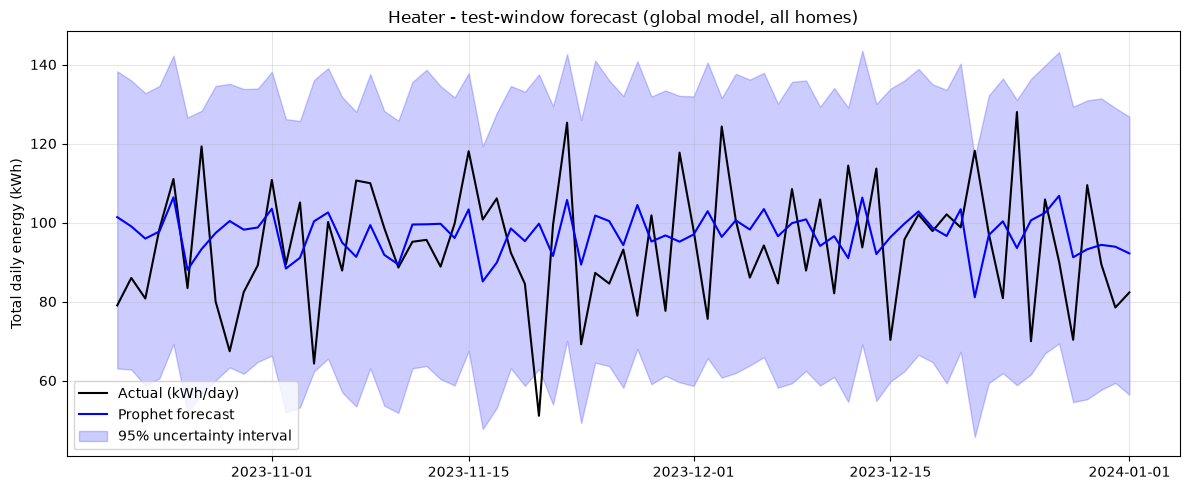

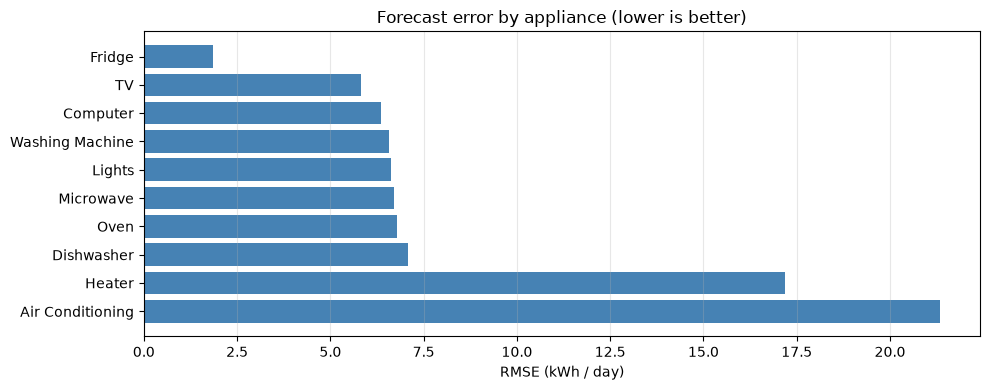

In [42]:
# ============================================================================
# CELL 15 - Visualise Forecast vs Reality + Error by Appliance
# ============================================================================
# Purpose : (a) overlay actuals, point forecast and 95% band for ONE appliance,
#           (b) bar-chart of RMSE across all appliance types (see which are
#               easy vs hard to forecast).

# --- (a) forecast vs reality for the Heater (examples, easy to read) ------
example = "Heater"
preds   = predictions[example]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(preds["measurement_datetime"], preds["actual"],     "k-",  lw=1.5, label="Actual (kWh/day)")
ax.plot(preds["measurement_datetime"], preds["yhat"],       "b-",  lw=1.5, label="Prophet forecast")
ax.fill_between(x=preds["measurement_datetime"],
                y1=preds["yhat_lower"],
                y2=preds["yhat_upper"],
                color="blue", alpha=0.20,
                label="95% uncertainty interval")
ax.set_title(label=f"{example} - test-window forecast (global model, all homes)")
ax.set_ylabel(ylabel="Total daily energy (kWh)")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- (b) RMSE per appliance -----------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.barh(summary_df["appliance"], width=summary_df["rmse_kwh"], color="steelblue")
ax2.invert_yaxis()
ax2.set_xlabel(xlabel="RMSE (kWh / day)")
ax2.set_title(label="Forecast error by appliance (lower is better)")
ax2.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()





In [43]:
# ============================================================================
# CELL 16 - Inference Helper (Next-Day Forecast for One Appliance)
# ============================================================================
# Purpose : production-friendly next-day forecast using the registry built in
#           CELL 14. Reuses the in-memory model when present (notebook flow)
#           and otherwise unpickles the model registered on disk, so the same
#           helper works from a standalone inference script.
from typing import Any


def _get_model(appliance: str):
    """Return the model object for `appliance` (memory first, then disk)."""
    if appliance in models:
        return models[appliance]["model"]

    # Normalize the registry value to a Path object so the type checker
    # sees a valid path-like object for the file API.
    registry_entry = model_registry[appliance]
    model_path_value = registry_entry.get("model_path")

    # Defensive guard against a mis-typed registry record from prior runs.
    # This keeps the downstream `Path` constructor honest: it must see a
    # scalar string, not a list/dict/None payload.
    if not isinstance(model_path_value, str):
        raise TypeError(
            f"Model path in registry for '{appliance}' must be a string. "
            f"Got {type(model_path_value).__name__} instead."
        )

    model_path = Path(model_path_value)

    # Defensive check: surface a cleaner error if the artifact was moved.
    if not model_path.exists():
        raise FileNotFoundError(f"Registered Prophet model not found: {model_path}")

    with model_path.open(mode="rb") as fh:
        return pickle.load(file=fh)


def predict_next_day(
    appliance: str,
    ds_next: str,           # "YYYY-MM-DD"
    avg_temp: float,        # expected outdoor temperature that day (C)
    hh_size: float,         # expected household size
    is_weekend: int,        # 0 (weekday) or 1 (weekend)
) -> dict[str, Any]:
    """Point forecast + 95% band for the next day of one appliance."""
    if appliance not in model_registry:
        raise KeyError(
            f"'{appliance}' is not in the model registry. "
            f"Available: {sorted(model_registry)}"
        )

    model = _get_model(appliance)

    # Prophet needs one df row per day with 'ds' plus the EXACT regressor names
    # registered at fit time (daily[app] names the weather column 'temp').
    future = pd.DataFrame(data={
        "ds":         pd.to_datetime([ds_next]),
        "temp":       [float(avg_temp)],
        "hh_size":    [float(hh_size)],
        "is_weekend": [int(is_weekend)],
    })

    fc = model.predict(future)   # one row per requested day

    return {
        "appliance":    appliance,
        "ds":           str(object=pd.to_datetime(arg=ds_next).date()),
        "yhat":         float(fc["yhat"].iloc[0]),
        "yhat_lower":   float(fc["yhat_lower"].iloc[0]),
        "yhat_upper":   float(fc["yhat_upper"].iloc[0]),
        "model_path":   model_registry[appliance]["model_path"],
        "split_date":   model_registry[appliance]["split_date"],
    }


In [44]:
# ============================================================================
# CELL 17 - Example Inference (Next-Day Forecast vs Reality)
# ============================================================================
# Use the Washing Machine model on the first held-out test day: feed the KNOWN
# regressor values for that day and compare the forecast to the actuals.
example_app  = "Washing Machine"


forecast = predict_next_day(
    appliance=example_app,
    ds_next=str(object=(pd.Timestamp.today().normalize() + pd.Timedelta(days=1)).date()),
    avg_temp=10.0,
    hh_size=3,
    is_weekend=1,
)

print(f"Next-day forecast for {forecast['appliance']} on {forecast['ds']}:")
print(f"  predicted : {forecast['yhat']:8.2f} kWh   (95% CI "
      f"{forecast['yhat_lower']:.2f} - {forecast['yhat_upper']:.2f})")
print(f"  model     : {forecast['model_path']}")

Next-day forecast for Washing Machine on 2026-09-15:
  predicted :    32.23 kWh   (95% CI 19.43 - 44.57)
  model     : C:\Users\USER\Documents\Gen AI Projects\AI-Powered-Smart-Home-Energy-Optimizer\Backend\Artifacts\Models\prophet_washing_machine.pkl


## What we learned & next steps

- The **global, per-appliance** Prophet models forecast *aggregate* daily energy for
  each appliance type across all 500 homes. Weather (outdoor temperature) is a genuine
  driver for heating-cooling appliances and is consumed as a regressor.
- Models, point forecasts with confidence bands, and per-appliance **MAE/RMSE/MAPE**
  are persisted under `Backend/artifacts/` for the API to consume.
- Engineering notes while building this pipeline:
  1. Forecast accuracy is measured with `scikit-learn` metrics (`mean_absolute_error`,
     `mean_squared_error` -> RMSE, `mean_absolute_percentage_error` -> MAPE).
  2. `show_progress` was removed from `Prophet.fit` (incompatible with the installed
     `cmdstanpy 1.3.0`) and the CSV is always read with `latin-1` encoding so the °C
     header survives intact.

### Suggested extensions
- **Personalisation**: the per-home daily panel `home_daily` built in CELL 8 is the
  perfect starting point - filter by `Home ID` (plus `Household Size`) to turn the
  global model into a per-home, per-appliance forecast. `appliance_daily` already
  holds the per-home-average series (`y` = kWh/home/day) for benchmarking.
- **Intra-day forecasts**: aggregate at hourly granularity and enable
  `daily_seasonality=True` to capture breakfast / evening peaks.
- **Covariates**: add a holiday calendar and `Household Size` as extra regressors.
- **Cross-validation**: `Prophet.cross_validation` with `performance_metrics` gives
  robust error estimates instead of a single hold-out window.
